# Read stats

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

custom_params = {"axes.spines.right": False, "axes.spines.top": False}

sns.set_theme(
    context="notebook",
    style="ticks", 
    palette="colorblind",
    font_scale=1.1,
    rc=custom_params
)

# For SVG output
plt.rcParams['svg.fonttype'] = 'none'
figdir = Path("../figures/svg")

In [63]:
samples = pd.read_csv("../sample_info.tsv", sep="\t") 
samples["Type"] = samples["IsSingleCell"].replace({True: "Single cell", False: "Bulk"})
human_samples = samples.query("Genome == 'Human'")

human_samples

,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,Type
0,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Single cell
1,P33410_1002,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,Single cell
2,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Single cell
3,P33410_1004,Q_E2_cell_04,True,Qiagen,MM1S cell line,Human,Single cell
4,P33410_1005,Q_F2_cell_05,True,Qiagen,MM1S cell line,Human,Single cell
5,P33410_1006,Q_G2_cell_06,True,Qiagen,MM1S cell line,Human,Single cell
7,P33410_1008,Q_A3_cell_07,True,Qiagen,MM1S cell line,Human,Single cell
8,P33410_1009,Q_B3_cell_08,True,Qiagen,MM1S cell line,Human,Single cell
9,P33410_1010,Q_C3_cell_09,True,Qiagen,MM1S cell line,Human,Single cell
10,P33410_1011,Q_D3_cell_10,True,Qiagen,MM1S cell line,Human,Single cell


In [64]:
paths = [
    "../analysis/downsample_qc/sarek_GRCh38/outdir/multiqc/GA_24_11_scWGS_downsampled_GRCh38_multiqc_report_data/multiqc_samtools_stats.txt",
    "../analysis/downsample_40M/sarek_GRCh38/outdir/multiqc/GA_24_11_scWGS_downsampled_GRCh38_multiqc_report_data/multiqc_samtools_stats.txt",
    "../analysis/qiagen_repli_g_full/sarek/multiqc/GA_24_11_scWGS_Qiagen_Full_GRCh38_multiqc_report_data/multiqc_samtools_stats.txt",
]
reads = ["2M", "40M", "full"]
data = []
for path, r in zip(paths, reads):
    d = pd.read_csv(path, sep="\t")
    
    d["reads"] = r
    d["NGI ID"] = d["Sample"].str.split(".").str[0]
    d = d.drop("Sample", axis=1)
    data.append(d)

data = pd.concat(data)
data = data.merge(samples, on="NGI ID")
data["percent_diff_chrom"] = 100 * data["pairs_on_different_chromosomes"] / data["reads_mapped"]
data["percent_wrong_orient"] = 100 * (data["outward_oriented_pairs"] + data["pairs_with_other_orientation"]) / data["reads_mapped"]
data["percent_outward_orient"] = 100 * data["outward_oriented_pairs"] / data["reads_mapped"]
data["percent_other_orient"] = 100 * data["pairs_with_other_orientation"] / data["reads_mapped"]
data["percent_non-primary_alignments"] = 100 * data["non-primary_alignments"] / data["reads_mapped"]
data["percent_supplementary_alignments"] = 100 * data["supplementary_alignments"] / data["reads_mapped"]
data.head()

,raw_total_sequences,filtered_sequences,sequences,is_sorted,1st_fragments,last_fragments,reads_mapped,reads_mapped_and_paired,reads_unmapped,reads_properly_paired,...,Kit,Sample,Genome,Type,percent_diff_chrom,percent_wrong_orient,percent_outward_orient,percent_other_orient,percent_non-primary_alignments,percent_supplementary_alignments
0,3935996.0,0.0,3935996.0,1.0,1967998.0,1967998.0,3935280.0,3935024.0,716.0,3802540.0,...,Qiagen,MM1S cell line,Human,Single cell,0.456969,7.235927,6.319525,0.916402,0.0,2.869554
1,3946922.0,0.0,3946922.0,1.0,1973461.0,1973461.0,3946317.0,3946104.0,605.0,3810594.0,...,Qiagen,MM1S cell line,Human,Single cell,0.423610,7.467190,6.494511,0.972679,0.0,2.999683
2,3951100.0,0.0,3951100.0,1.0,1975550.0,1975550.0,3950471.0,3950194.0,629.0,3814704.0,...,Qiagen,MM1S cell line,Human,Single cell,0.428734,7.798868,6.842830,0.956038,0.0,3.059610
3,3947860.0,0.0,3947860.0,1.0,1973930.0,1973930.0,3947165.0,3946892.0,695.0,3810766.0,...,Qiagen,MM1S cell line,Human,Single cell,0.430638,7.948490,6.988053,0.960436,0.0,3.243011
4,3950382.0,0.0,3950382.0,1.0,1975191.0,1975191.0,3949639.0,3949390.0,743.0,3815156.0,...,Qiagen,MM1S cell line,Human,Single cell,0.417456,7.715490,6.763251,0.952239,0.0,3.071471


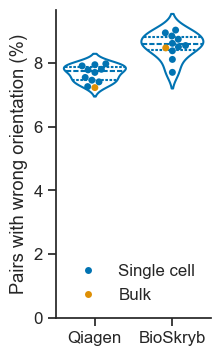

In [91]:
d = data[data["reads"] == "40M"]
fig, ax = plt.subplots(figsize=(2, 4))
ax = sns.violinplot(
    data=d.query("Type == 'Single cell'"), 
    x="Kit", 
    y="percent_wrong_orient", 
    inner="quart", 
    fill=None, 
    density_norm="width", 
    ax=ax
)
ax = sns.swarmplot(
    data=d, 
    x="Kit", 
    y="percent_wrong_orient", 
    hue="Type", 
    ax=ax
)
ax.set_ylim(bottom=0)
ax.set_ylabel("Pairs with wrong orientation (%)")
ax.set_xlabel("")
plt.legend(frameon=False, framealpha=0)
plt.savefig(figdir / "discordant_wrong_orient.svg", bbox_inches="tight")

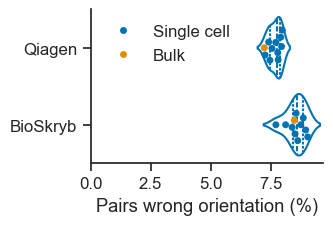

In [100]:
d = data[data["reads"] == "40M"]
fig, ax = plt.subplots(figsize=(3, 2))
ax = sns.violinplot(
    data=d.query("Type == 'Single cell'"), 
    y="Kit", 
    x="percent_wrong_orient", 
    inner="quart", 
    density_norm="width", 
    fill=None, 
    ax=ax
)
ax = sns.swarmplot(
    data=d, 
    y="Kit", 
    x="percent_wrong_orient", 
    hue="Type", 
    ax=ax)
ax.set_xlim(left=0)
ax.set_xlabel("Pairs wrong orientation (%)")
ax.set_ylabel("")
plt.legend(frameon=False, framealpha=0)
plt.savefig(figdir / "discordant_wrong_orient_h.svg", bbox_inches="tight")

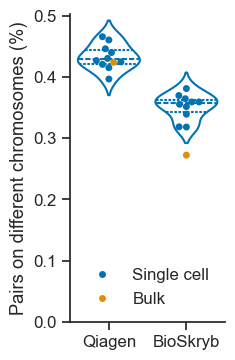

In [93]:
d = data[data["reads"] == "40M"]
fig, ax = plt.subplots(figsize=(2, 4))
ax = sns.violinplot(
    data=d.query("Type == 'Single cell'"),
    density_norm="width", 
    x="Kit", y="percent_diff_chrom", inner="quart", fill=None, ax=ax
)
ax = sns.swarmplot(
    data=d,
    x="Kit", y="percent_diff_chrom", hue="Type", ax=ax
)
ax.set_ylim(bottom=0)
ax.set_ylabel("Pairs on different chromosomes (%)")
ax.set_xlabel("")
plt.legend(frameon=False, framealpha=0)
plt.savefig(figdir / "discordant_translocations.svg", bbox_inches="tight")

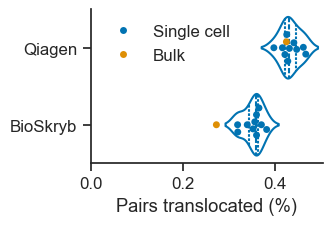

In [99]:
d = data[data["reads"] == "40M"]
fig, ax = plt.subplots(figsize=(3, 2))
ax = sns.violinplot(
    data=d.query("Type == 'Single cell'"),
    density_norm="width", 
    y="Kit", x="percent_diff_chrom", inner="quart", fill=None, ax=ax
)
ax = sns.swarmplot(data=d, y="Kit", x="percent_diff_chrom", hue="Type", ax=ax)
ax.set_xlim(left=0)
ax.set_xlabel("Pairs translocated (%)")
ax.set_ylabel("")
plt.legend(frameon=False, framealpha=0)
plt.savefig(figdir / "discordant_translocations_h.svg", bbox_inches="tight")

<Axes: xlabel='Kit', ylabel='reads_mapped_and_paired_percent'>

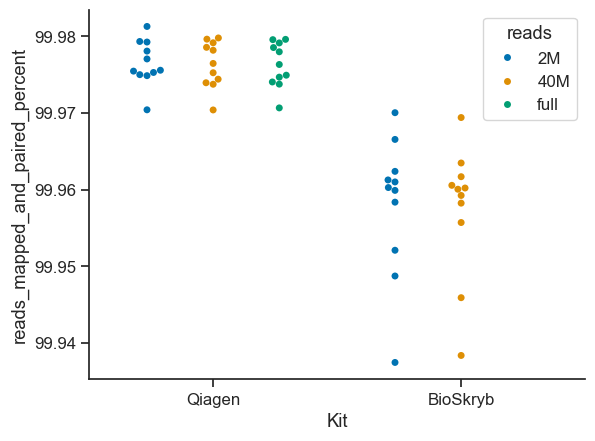

In [ ]:
sns.swarmplot(data=data, x="Kit", y="reads_mapped_and_paired_percent", hue="reads", dodge=True)

<Axes: xlabel='Kit', ylabel='reads_MQ0_percent'>

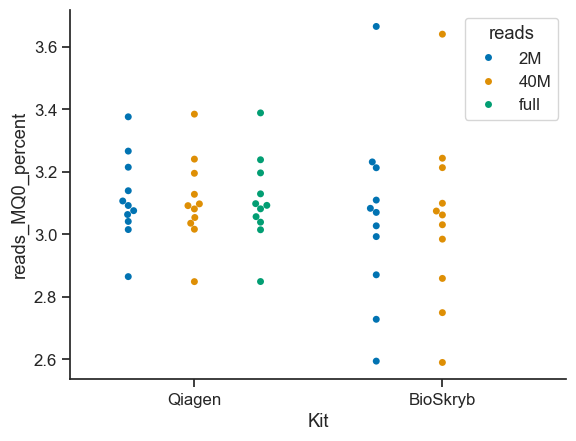

In [ ]:
sns.swarmplot(data=data, x="Kit", y="reads_MQ0_percent", hue="reads", dodge=True)

<Axes: xlabel='Kit', ylabel='error_rate'>

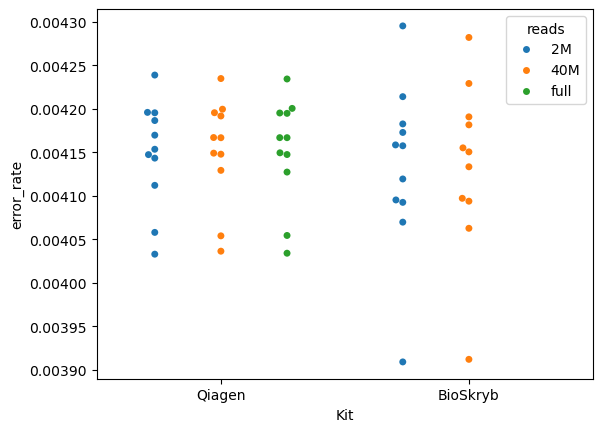

In [29]:
sns.swarmplot(data=data, x="Kit", y="error_rate", hue="reads", dodge=True)